# Feature Evaluation - US Firm Characteristics

Evaluation of Ch8 financial features against 1-month forward returns.
Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Evaluate 57 financial features with HAC-adjusted IC
- Apply Benjamini-Hochberg FDR to control false discovery across the factor zoo
- Assess quantile monotonicity and fold-level stability (10 walk-forward folds)
- Produce a triage ledger (PROCEED / REVISE / STOP) for Ch11 model selection

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation & Triage)

**Prerequisites**: Run `03_financial_features.py` first.

In [1]:
"""Feature Evaluation - US Firm Characteristics

Evaluation of Ch8 financial features against forward return labels.
Produces triage decisions for Ch11 modeling.
"""

import json
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import spearmanr

from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

In [2]:
# Production defaults
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "us_firm_characteristics"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

## Section 0: Load Artifacts

Load pre-computed financial features and labels, then build
the evaluation panel.

In [4]:
# Load features
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")

# Load primary label
PRIMARY_LABEL_FILE = "fwd_ret_1m.parquet"
label_df = pl.read_parquet(CASE_DIR / "labels" / PRIMARY_LABEL_FILE)

# Auto-detect label column
label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

# Load CV config for fold-level analysis
with open(CASE_DIR / "config" / "cv_config.json") as f:
    cv_config = json.load(f)

# The corrected converter preserves the anonymous firm axis within the source block.
JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"
HOLDOUT_START = date.fromisoformat(cv_config["holdout_start"])

In [5]:
# Identify feature columns
financial_cols = [c for c in features.columns if c not in JOIN_COLS]
all_feature_cols = financial_cols

# Build the full panel, then seal the holdout from every diagnostic and decision.
full_panel = features.join(label_df, on=JOIN_COLS, how="inner", validate="1:1")
assert len(full_panel) == len(features) == len(label_df)
eval_panel = full_panel.filter(pl.col(DATE_COL) < HOLDOUT_START)

# Optional: reduce universe for fast dev (Papermill parameter)
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("symbol").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("symbol").is_in(top["symbol"]))

n_rows = len(eval_panel)
n_symbols_avg = (
    eval_panel.group_by(DATE_COL).agg(pl.col("symbol").n_unique()).select("symbol").mean().item()
)
n_dates = eval_panel[DATE_COL].n_unique()
print(
    f"Pre-holdout panel: {n_rows:,} rows, ~{n_symbols_avg:.0f} stocks/month avg, {n_dates} months"
)
print(f"Sealed holdout: {len(full_panel) - len(eval_panel):,} rows from {HOLDOUT_START}")
print(f"Features: {len(financial_cols)} financial")
print(f"Label: {label_col}")

Pre-holdout panel: 780,882 rows, ~2503 stocks/month avg, 312 months
Sealed holdout: 23,648 rows from 2016-01-01
Features: 57 financial
Label: fwd_ret_1m


## 0.5 Data Quality Gate

Verify upstream artifacts are free of critical defects before evaluation.

In [6]:
from utils.data_quality import validate_modeling_inputs

validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=20.0,  # 1-month returns (max observed ~19.0, small caps)
    fail_on_critical=True,
)

Data Quality Gate: ALL CLEAR


{'issues': [], 'n_critical': 0, 'n_warning': 0}

## Section 1: Correctness Screens

Check coverage before evaluating predictive power. Features below 70%
non-null are flagged. The released characteristics deliberately update at
different frequencies, so repeated values can be economically correct rather
than a stale-feed defect. The persistent identifier nevertheless lets downstream
models construct valid longitudinal histories.

In [7]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

# Correctness gate: coverage >= 70%.
correctness = {feat: coverage[feat] >= 0.70 for feat in all_feature_cols}

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL (coverage-only)")
print(f"Persistent anonymous firms in development panel: {eval_panel['symbol'].n_unique():,}")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 57 PASS, 0 FAIL (coverage-only)
Persistent anonymous firms in development panel: 9,793


## Section 2: Univariate Association (IC + HAC)

For each feature, compute a time series of cross-sectional Spearman IC
(one IC per month across ~2,483 stocks), then test significance with
HAC standard errors (Newey-West, four lags for the monthly IC series).

In [8]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]
HAC_MAXLAGS = 4
MIN_PERIODS = 30  # ~2,483 stocks/month

# Detect date-level features (zero cross-sectional variance)
cs_std_df = eval_panel.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Date-level features (zero CS variance): {sorted(date_level_features)}")

In [9]:
# Batch IC computation: one pass over months, all features at once
cs_features = [f for f in evaluable_features if f not in date_level_features]
cols_needed = [DATE_COL] + cs_features + [label_col]
eval_sub = eval_panel.select(cols_needed).drop_nulls(subset=[label_col])

dates_list = eval_sub[DATE_COL].unique().sort().to_list()
n_total = len(dates_list)

ic_series_data = {feat: [] for feat in cs_features}

for i, dt in enumerate(dates_list):
    cross_section = eval_sub.filter(pl.col(DATE_COL) == dt)
    n_obs = len(cross_section)
    if n_obs < MIN_PERIODS:
        continue

    label_arr = cross_section[label_col].to_numpy()
    label_valid = ~np.isnan(label_arr)

    for feat in cs_features:
        feat_arr = cross_section[feat].to_numpy()
        valid_mask = label_valid & ~np.isnan(feat_arr)
        n_valid = int(valid_mask.sum())
        if n_valid >= MIN_PERIODS:
            ic_val, _ = spearmanr(feat_arr[valid_mask], label_arr[valid_mask])
            if not np.isnan(ic_val):
                ic_series_data[feat].append((dt, float(ic_val), n_valid))

    if (i + 1) % 50 == 0:
        print(f"  IC progress: {i + 1}/{n_total} months")

print(f"  IC progress: {n_total}/{n_total} months (done)")

  IC progress: 50/312 months


  IC progress: 100/312 months


  IC progress: 150/312 months


  IC progress: 200/312 months


  IC progress: 250/312 months


  IC progress: 300/312 months


  IC progress: 312/312 months (done)


In [10]:
# Convert to DataFrames and compute HAC stats
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    data = ic_series_data[feat]
    if len(data) < 20:
        continue
    dates_f, ics_f, nobs_f = zip(*data, strict=False)
    ic_df = pl.DataFrame({DATE_COL: list(dates_f), "ic": list(ics_f), "n_obs": list(nobs_f)})
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"IC computed for {len(ic_results)} cross-sectional features")
print(f"Skipped {len(date_level_features)} date-level features")

IC computed for 57 cross-sectional features
Skipped 0 date-level features


### Fold-Level Stability

Per-fold IC using the 10 walk-forward splits. Sign consistency measures
what fraction of folds show the same IC sign as the overall mean. A
feature that works in 9/10 folds is more trustworthy than one that works
in 5/10 despite a similar overall IC.

In [11]:
fold_stats = {}
for feat in ic_results:
    fold_ics = []
    for split in cv_config["splits"]:
        ts = ic_timeseries[feat]
        fold_ic = ts.filter(
            (pl.col(DATE_COL) >= date.fromisoformat(split["val_start"]))
            & (pl.col(DATE_COL) <= date.fromisoformat(split["val_end"]))
        )
        if len(fold_ic) >= 5:
            fold_ics.append(fold_ic["ic"].mean())

    if fold_ics:
        overall_sign = 1 if ic_results[feat]["mean_ic"] > 0 else -1
        sign_consistency = sum(1 for ic in fold_ics if (ic > 0) == (overall_sign > 0)) / len(
            fold_ics
        )
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

print(f"Fold stats computed for {len(fold_stats)} features")

Fold stats computed for 57 features


## Section 3: Multiple Testing (BH-FDR)

With 57 features in the classic "factor zoo," multiple testing correction
is essential. We distinguish naive mean tests, unadjusted HAC tests, and
Benjamini-Hochberg FDR at 5%.

In [12]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    }
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(
    1 for feature in feature_names if abs(ic_results[feature]["naive_t_stat"]) > 1.96
)
n_significant_hac = sum(1 for p in p_values if p < 0.05)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
multiple_testing_ratio = n_significant_hac / max(n_significant_fdr, 1)

print(f"Naive significant (|t| > 1.96): {n_significant_naive}")
print(f"Unadjusted HAC significant (p < 0.05): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Naive/HAC ratio: {inflation_hac:.2f}x")
print(f"HAC/FDR multiplicity ratio: {multiple_testing_ratio:.2f}x")

Naive significant (|t| > 1.96): 41
Unadjusted HAC significant (p < 0.05): 40
FDR significant (q < 0.05):   38
Naive/HAC ratio: 1.02x
HAC/FDR multiplicity ratio: 1.05x


### IC Strength and HAC Adjustment

The first chart ranks the leading features by absolute IC. The second compares
naive and HAC t-statistics on equal axes.

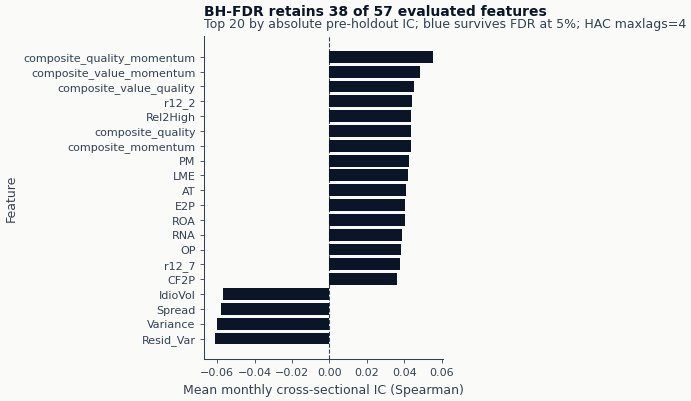

In [13]:
top_n = min(20, len(eval_summary))
top = eval_summary.head(top_n).sort("ic_mean")

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
bar_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in top["fdr_sig"].to_list()
]
ax.barh(top["feature"].to_list(), top["ic_mean"].to_list(), color=bar_colors)
zero_line(ax, at=0, axis="x")
ax.set_xlabel("Mean monthly cross-sectional IC (Spearman)")
ax.set_ylabel("Feature")
add_message_title(
    ax,
    f"BH-FDR retains {n_significant_fdr} of {len(feature_names)} evaluated features",
    subtitle=f"Top {top_n} by absolute pre-holdout IC; blue survives FDR at 5%; HAC maxlags={HAC_MAXLAGS}",
)
plt.show()

HAC inference changes the scale of the mean tests but not the underlying IC
estimates. Points below the diagonal have smaller HAC t-statistics.

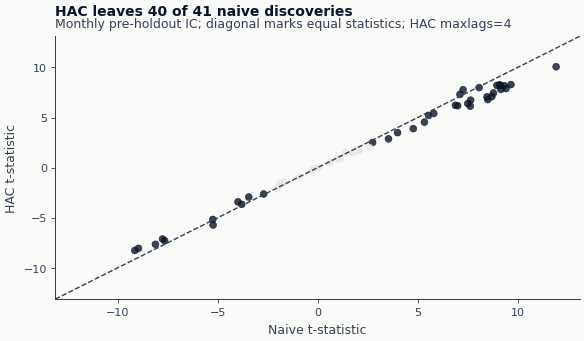

In [14]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
point_colors = [
    COLORS["blue"] if significant else COLORS["silver_muted"]
    for significant in eval_summary["fdr_sig"].to_list()
]
ax.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    c=point_colors,
    s=24,
    alpha=0.8,
)
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
ax.plot(
    [-max_t, max_t],
    [-max_t, max_t],
    linestyle="--",
    color=COLORS["neutral"],
    linewidth=1,
)
ax.set_xlim(-max_t, max_t)
ax.set_ylim(-max_t, max_t)
ax.set_xlabel("Naive t-statistic")
ax.set_ylabel("HAC t-statistic")
add_message_title(
    ax,
    f"HAC leaves {n_significant_hac} of {n_significant_naive} naive discoveries",
    subtitle=f"Monthly pre-holdout IC; diagonal marks equal statistics; HAC maxlags={HAC_MAXLAGS}",
)
plt.show()

**Interpretation**: With ~2,483 stocks per month providing ample cross-sectional
breadth, even small IC values can achieve statistical significance. HAC inference
allows serial dependence in the monthly IC series, while FDR controls the expected
fraction of false discoveries among all features declared significant.

## Section 4: Shape Diagnostics

Quantile monotonicity analysis: does the label (1-month return) spread
monotonically across feature quintiles? A monotone relationship is easier
for linear models (Ch11) to capture; non-monotone relationships may need
tree-based models (Ch12).

In [15]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]

if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([DATE_COL, feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue
    valid = valid.with_columns(
        ((pl.col(feat).rank("average").over(DATE_COL) - 1) * N_QUANTILES / pl.len().over(DATE_COL))
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile_index")
    )
    q_means = valid.group_by("quantile_index").agg(pl.col(label_col).mean()).sort("quantile_index")
    means = q_means[label_col].to_list()
    if len(means) != N_QUANTILES:
        continue
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

print(f"Quantile analysis for {len(quantile_spreads)} features")

Quantile analysis for 15 features


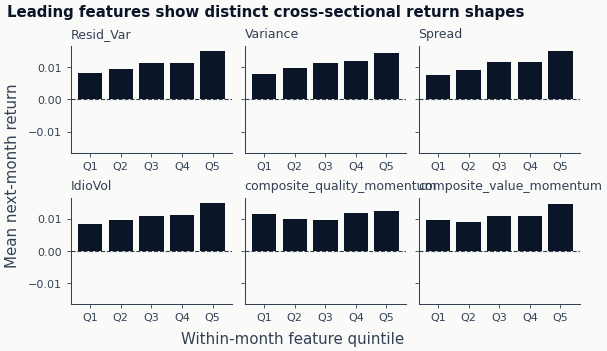

In [16]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    all_means = [
        value for feature in feats_to_show for value in quantile_spreads[feature]["q_means"]
    ]
    y_limit = max(abs(min(all_means)), abs(max(all_means))) * 1.1
    fig, axes = plt.subplots(2, 3, figsize=FIGSIZE["grid_2x3"], sharey=True)
    for idx, feat in enumerate(feats_to_show):
        ax = axes.flat[idx]
        q_means = quantile_spreads[feat]["q_means"]
        ax.bar(
            [f"Q{i + 1}" for i in range(len(q_means))],
            q_means,
            color=COLORS["blue"],
        )
        zero_line(ax)
        ax.set_ylim(-y_limit, y_limit)
        ax.set_title(feat, fontsize=9)
    fig.supylabel("Mean next-month return")
    fig.supxlabel("Within-month feature quintile")
    fig.suptitle(
        "Leading features show distinct cross-sectional return shapes",
        color=COLORS["blue"],
        fontweight="semibold",
        x=0.01,
        ha="left",
    )
    plt.show()

**Interpretation**: Monotone quantile profiles (steady increase or decrease
from Q1 to Q5) indicate linear factor structure suitable for Ridge/Lasso
in Ch11. Non-monotone profiles (U-shaped or inverted-U) suggest interaction
effects better captured by tree-based models in Ch12.

## Section 5: Redundancy & Feature Families

Pairwise Spearman correlation matrix to identify redundant features,
and family-level IC aggregation to assess which categories contribute
most signal.

In [17]:
def assign_feature_family(feature_name: str) -> str:
    """Map feature name to family for US firm characteristics."""
    name = feature_name.lower()
    families = [
        # Composites and interactions first (prefix-based, must match before single-char)
        (["composite_"], "composite"),
        (["interaction_"], "interaction"),
        # Factor families
        (["beme", "e2p", "cf2p", "s2p", "d2p", "a2me"], "value"),
        (["roe", "roa", "prof", "op", "pcm", "pm", "ni", "sga2s", "fc2y", "rna"], "quality"),
        (["r12_", "r2_1", "r36_", "st_rev", "lt_rev", "rel2high", "suv"], "momentum"),
        (["beta", "idiovol", "variance", "resid_var", "mktbeta", "spread"], "risk"),
        (["investment", "dpi2a", "noa", "oa", "ac", "d2a"], "investment"),
        (["lme", "at", "q", "c", "cf", "lev", "ol", "cto", "ato", "lturnover"], "size_leverage"),
    ]
    for prefixes, family in families:
        if any(p in name for p in prefixes):
            return family
    return "other"

In [18]:
# Assign families
families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

In [19]:
# Pairwise correlation (sample every Nth month for efficiency)
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

top_corr_pairs = sorted(high_corr_pairs, key=lambda item: abs(item[2]), reverse=True)[:15]
pair_summary = pl.DataFrame(
    {
        "pair": [f"{left} / {right}" for left, right, _ in top_corr_pairs],
        "correlation": [float(correlation) for _, _, correlation in top_corr_pairs],
    }
).sort("correlation")
print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |corr| > 0.7: 42


In [20]:
# Family-level IC summary
family_ic: dict[str, list] = {}
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
else:
    fam_df = pl.DataFrame(
        schema={
            "family": pl.Utf8,
            "n_features": pl.Int64,
            "avg_abs_ic": pl.Float64,
            "avg_ic": pl.Float64,
            "n_fdr_sig": pl.Int64,
        }
    )

### Redundancy and Family Strength

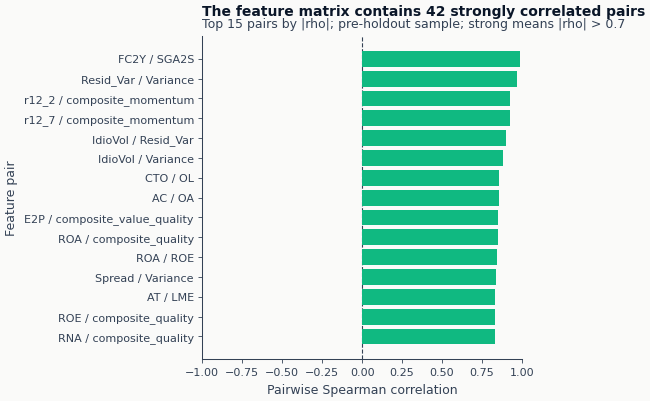

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
pair_colors = [
    COLORS["positive"] if value >= 0 else COLORS["negative"]
    for value in pair_summary["correlation"].to_list()
]
ax.barh(
    pair_summary["pair"].to_list(),
    pair_summary["correlation"].to_list(),
    color=pair_colors,
)
zero_line(ax, at=0, axis="x")
ax.set_xlim(-1, 1)
ax.set_xlabel("Pairwise Spearman correlation")
ax.set_ylabel("Feature pair")
add_message_title(
    ax,
    f"The feature matrix contains {len(high_corr_pairs)} strongly correlated pairs",
    subtitle="Top 15 pairs by |rho|; pre-holdout sample; strong means |rho| > 0.7",
)
plt.show()

Family averages show where predictive strength is concentrated without treating
a family mean as an independent significance test.

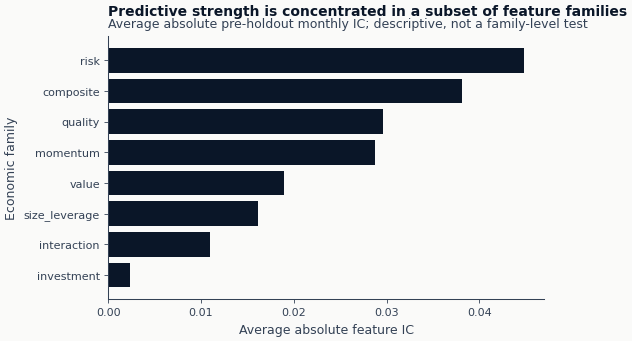

In [22]:
plot_families = fam_df.sort("avg_abs_ic")
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.barh(
    plot_families["family"].to_list(),
    plot_families["avg_abs_ic"].to_list(),
    color=COLORS["blue"],
)
ax.set_xlabel("Average absolute feature IC")
ax.set_ylabel("Economic family")
add_message_title(
    ax,
    "Predictive strength is concentrated in a subset of feature families",
    subtitle="Average absolute pre-holdout monthly IC; descriptive, not a family-level test",
)
plt.show()

**Interpretation**: Value, quality, and size features form correlated clusters,
expected from the factor literature. The composite features are intentionally
constructed from these clusters, so high within-family correlation is by design.
Regularized linear and tree-based models provide complementary ways to manage
this redundancy downstream.

## Section 6: Triage & Handoff

Apply triage rules to categorize features for Ch11 model selection:

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant at 5% OR (sign_consistency > 60% AND abs(IC) > 0.01) |
| **STOP** | Correctness FAIL (coverage < 70%) |
| **REVISE** | Everything else (evaluate in multivariate context in Ch11) |

In [23]:
IC_THRESHOLD = 0.01  # Monthly rebalance

triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### Build Triage Ledger

In [24]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = match["fdr_p"][0]
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")

print(f"Triage ledger: {display_path(EVAL_DIR / 'triage_ledger.parquet')}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger: output/us_firm_signoff_20260721/us_firm_characteristics/evaluation/triage_ledger.parquet
shape: (2, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 40  │
│ REVISE   ┆ 17  │
└──────────┴─────┘


### Save IC Time Series

In [25]:
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {len(ic_ts_all):,} rows, {ic_ts_all['feature'].n_unique()} features")

IC time series: 17,784 rows, 57 features


### Summarize the Triage Decision

In [26]:
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

sorted_by_ic = sorted(ic_results.items(), key=lambda x: x[1].get("mean_ic") or 0, reverse=True)
best = sorted_by_ic[0] if sorted_by_ic else (None, {})
worst = sorted_by_ic[-1] if sorted_by_ic else (None, {})

In [27]:
print(f"PROCEED: {len(proceed_features)} features")
print(f"REVISE: {len(revise_features)} features")
print(f"STOP: {len(stop_features)} features")

promoted_summary = (
    triage_ledger.filter(pl.col("decision") == "PROCEED")
    .select("feature", "family", "ic_mean", "hac_t", "fdr_sig", "sign_consistency")
    .sort("ic_mean", descending=True)
)
promoted_summary

PROCEED: 40 features
REVISE: 17 features
STOP: 0 features


feature,family,ic_mean,hac_t,fdr_sig,sign_consistency
str,str,f64,f64,bool,f64
"""composite_quality_momentum""","""composite""",0.055185,8.279915,true,0.9
"""composite_value_momentum""","""composite""",0.048183,8.214209,true,0.8
"""composite_value_quality""","""composite""",0.045009,8.249365,true,1.0
"""r12_2""","""momentum""",0.043978,6.221533,true,0.8
"""Rel2High""","""momentum""",0.043728,5.206638,true,0.8
…,…,…,…,…,…
"""NI""","""quality""",-0.031686,-7.11826,true,1.0
"""IdioVol""","""risk""",-0.056994,-8.049856,true,1.0
"""Spread""","""risk""",-0.058055,-7.293529,true,1.0


### Quality Gate Verdict

**PASS.** The triage retains features that survive false-discovery control or
combine economically meaningful IC with stable signs across the ten canonical
validation folds. The broad monthly cross-section gives high statistical power,
so effect size, fold stability, and multiplicity all matter for promotion.

## Key Takeaways

1. **Large breadth drives significance**: With ~2,483 stocks per month,
   even modest IC values achieve statistical significance. FDR correction
   is essential to separate genuine signal from noise in this factor zoo.

2. **Composite features are competitive**: Cross-family combinations appear
   among the stronger IC estimates, but correlated inputs mean downstream
   regularization remains important.

3. **Economic families differ**: Momentum, profitability, size, and risk
   characteristics contribute signals with different signs and redundancy
   patterns; predictive IC does not establish causality.

4. **Identity supports longitudinal validation**: Anonymous symbols persist
   within the released source block, so fold stability and downstream firm
   histories are meaningful even though the public archive omits PERMNO.

**Next**: The triage ledger above defines the feature list for Ch11
Ridge/Lasso modeling.
**Book**: Chapter 8.5 discusses feature evaluation and the FDR framework.